In [65]:
# Define the data for the table
data = {
    'Task': [
        'Data Preprocessing', 'Image Augmentation', 'Train and test data handled correctly',
        'Gaussian Blur, Histogram Equalization and Intensity thresholds', 'Model Trained', 
        'AUC and Confusion Matrix Computed', 'Overfitting/Underfitting checked and handled',
        'Empirical Tuning', '1st Round of Tuning', '2nd Round of Tuning'
    ],
    'Sub-task': [
        'Scaling and Resizing', 'Done/Not Done', 'Done/Not Done', 'Done/Not Done', 'Training Time?',
        'Done/Not Done', 'Done/Not Done', 'Interpretability Implemented', 'Issue Faced/Fixed', 'Issue Faced/Fixed'
    ],
    'Comments': [
        'Done', 'Done', 'Done', 'Done', 'Done',
        'Done', 'Done', 'Done', 'Partially Done', 'Partially Done'
    ]
}

# Create a DataFrame
Task = pd.DataFrame(data)

# Display the table
Task


,Task,Sub-task,Comments
0,Data Preprocessing,Scaling and Resizing,Done
1,Image Augmentation,Done/Not Done,Done
2,Train and test data handled correctly,Done/Not Done,Done
3,"Gaussian Blur, Histogram Equalization and Inte...",Done/Not Done,Done
4,Model Trained,Training Time?,Done
5,AUC and Confusion Matrix Computed,Done/Not Done,Done
6,Overfitting/Underfitting checked and handled,Done/Not Done,Done
7,Empirical Tuning,Interpretability Implemented,Done
8,1st Round of Tuning,Issue Faced/Fixed,Partially Done
9,2nd Round of Tuning,Issue Faced/Fixed,Partially Done


## Imports

In [1]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, Concatenate
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import gc
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from tensorflow.keras.regularizers import l2


## Load file

In [2]:
# Paths
csv_path = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.csv"
image_dir = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"


In [3]:
# Load CSV
df = pd.read_csv(csv_path)

# Check class distribution
print(df['label'].value_counts())

label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


## Splitting

In [4]:
# Balance classes (Sample 20,000 images equally across classes)
min_class_size = df['label'].value_counts().min()  # Smallest class size
sample_size = min(min_class_size, 20000 // df['label'].nunique())  # Max per class

# Create an empty list to store the sampled data
sampled_data = []

# Loop through each group and sample the data
for label, group in df.groupby('label'):
    sampled_group = group.sample(sample_size, random_state=42)
    sampled_data.append(sampled_group)

# Concatenate the sampled data back into a DataFrame
df_balanced = pd.concat(sampled_data).reset_index(drop=True)

# Split into training and testing
train_df, test_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['label'], random_state=42)
# Extract labels for training and testing sets
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Training: {len(train_df)}, Testing: {len(test_df)}")


Training: 6712, Testing: 1678


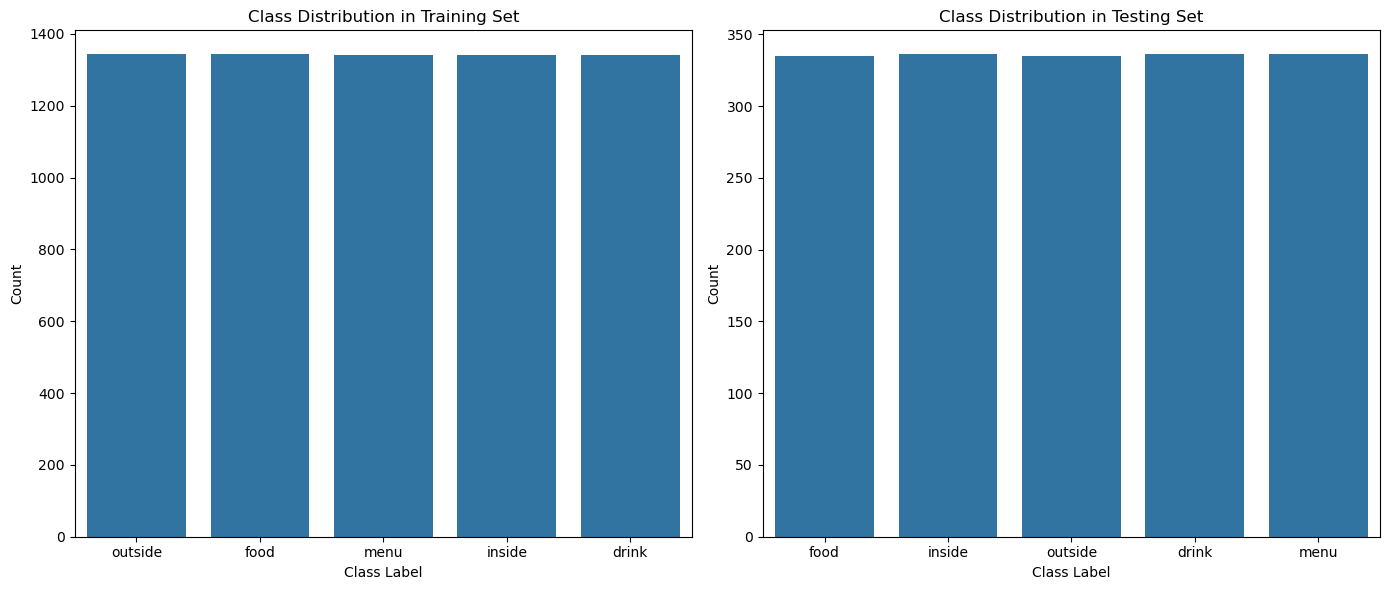

In [5]:
# Visualize the class distribution for training and testing sets without palette argument
plt.figure(figsize=(14, 6))

# Subplot for training set distribution
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='label')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Count')

# Subplot for testing set distribution
plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x='label')
plt.title('Class Distribution in Testing Set')
plt.xlabel('Class Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


## Preprocessing

In [6]:
# Preprocessing function
def preprocess_image(img_path):
    print(f"Loading image: {img_path}")  
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Unable to load image at {img_path}")
        return None  # Return None if image is not loaded
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))  
    
    # Apply Gaussian Blur
    img = cv2.GaussianBlur(img, (5,5), 0)
    
    # Apply Histogram Equalization
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # Normalize using float32 for lower memory usage
    img = img.astype(np.float32) / 255.0
    return img

# Data Generator with Augmentation
datagen = ImageDataGenerator(rotation_range=15, 
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             horizontal_flip=True)


In [7]:
def load_images(df, image_dir):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        # Construct the image path dynamically for each image
        img_path = os.path.join(image_dir, str(row['photo_id']) + '.jpg')
        
        if os.path.exists(img_path):  # Check if file exists
            img = preprocess_image(img_path)
            if img is not None:  # Skip None images
                images.append(img)
                labels.append(row['label'])
        else:
            print(f"Warning: Image {img_path} not found.")
        
        # Clear memory after each iteration to avoid accumulation
        del img
        gc.collect()
    
    return np.array(images), np.array(labels)


In [8]:
# Load images
X_train, y_train = load_images(train_df, image_dir)
X_test, y_test = load_images(test_df, image_dir)

print(f"Loaded {len(X_train)} training and {len(X_test)} testing images")

Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\XWN1IaTP0nNivqPfz4UPuw.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\MUlb1EqSMEGd8tkEeMK6Zg.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\AHZeI38pU1QhUGYDxQ69jQ.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\ttID6XIx1BWn6e-nngSwrQ.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\Yh22JtHwWMp7YC4-B2sMug.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\o5_He93PD_AhLL7p6ds6-A.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\LOg53LHze1Yl1D7v_bOUFQ.jpg
Loading image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_p

## Feature extraction using VGG16 model

In [9]:
# Load the pre-trained VGG16 model without the top (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False)

# Extract features from images using VGG16
def extract_features(images):
    features = base_model.predict(images, batch_size=32)  
    return features 

# Extract features for both train and test images
print("Extracting features for training data...")
X_train_features = extract_features(X_train)
print("Extracting features for testing data...")
X_test_features = extract_features(X_test)


Extracting features for training data...
210/210 ━━━━━━━━━━━━━━━━━━━━ 1176s 6s/step
Extracting features for testing data...
53/53 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step


In [10]:
# Flatten the features extracted by VGG16
print("Flattening features...")
X_train_features = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_features = X_test_features.reshape(X_test_features.shape[0], -1)

print(f"X_train_features shape: {X_train_features.shape}")
print(f"X_test_features shape: {X_test_features.shape}")

Flattening features...
X_train_features shape: (6706, 25088)
X_test_features shape: (1678, 25088)


## Model training

In [26]:
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_test are the labels as strings
label_encoder = LabelEncoder()

# Convert string labels to integers
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Update the model input shape
additional_input = Input(shape=(25088,))  

# Dense layers for classification
x = Dense(512, activation='relu')(additional_input)
x = Dropout(0.5)(x)

# Output layer with softmax for multi-class classification
output = Dense(len(df['label'].unique()), activation='softmax')(x)

# Create the model
model = Model(inputs=[additional_input], outputs=output)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Model summary
print("Model summary:")
model.summary()


# Now, train the model using the encoded labels
history = model.fit(
    X_train_features, y_train_encoded,
    validation_data=(X_test_features, y_test_encoded),
    epochs=10,
    batch_size=32
) 

Model summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,848,133 (49.01 MB)

 Trainable params: 12,848,133 (49.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


C:\Users\JISNA\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_35']. Received: the structure of inputs=*
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.6589 - loss: 0.8676 - val_accuracy: 0.8135 - val_loss: 0.5047
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.8526 - loss: 0.4042 - val_accuracy: 0.8486 - val_loss: 0.4078
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.8996 - loss: 0.2829 - val_accuracy: 0.8647 - val_loss: 0.3899
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.9240 - loss: 0.2112 - val_accuracy: 0.8719 - val_loss: 0.3842
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.9532 - loss: 0.1471 - val_accuracy: 0.8522 - val_loss: 0.4130
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9732 - loss: 0.1036 - val_accuracy: 0.8498 - val_loss: 0.4549
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.9806 - loss: 0.0796 - val_accuracy: 0.8647 - val_loss: 0.4220
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.9865 - loss: 0.0635 - val_accurac

In [27]:
test_loss, test_accuracy = model.evaluate(X_test_features, y_test_encoded)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8779 - loss: 0.4143
Test Loss: 0.4348815977573395
Test Accuracy: 0.8671036958694458


In [28]:
# Check the unique classes in y_test
unique_classes = np.unique(y_test)
print("Unique classes in y_test:", unique_classes)


Unique classes in y_test: ['drink' 'food' 'inside' 'menu' 'outside']


In [29]:
# Check unique predicted classes
unique_pred_classes = np.unique(y_pred_classes)
print("Unique predicted classes in y_pred:", unique_pred_classes)

Unique predicted classes in y_pred: [0 1 2 3 4]


## Confusion matrix and ROC

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


<Figure size 800x600 with 0 Axes>

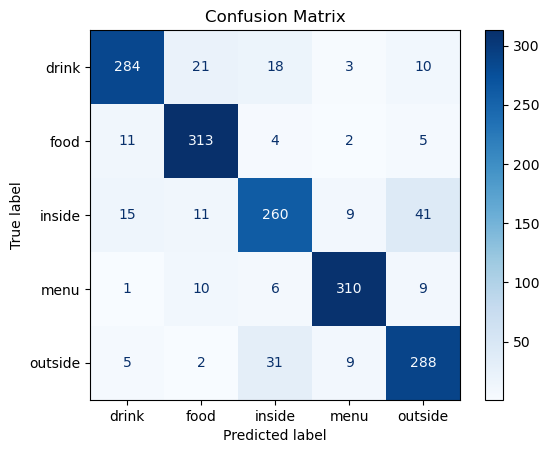

AUC (macro-average): 0.9793501551888507


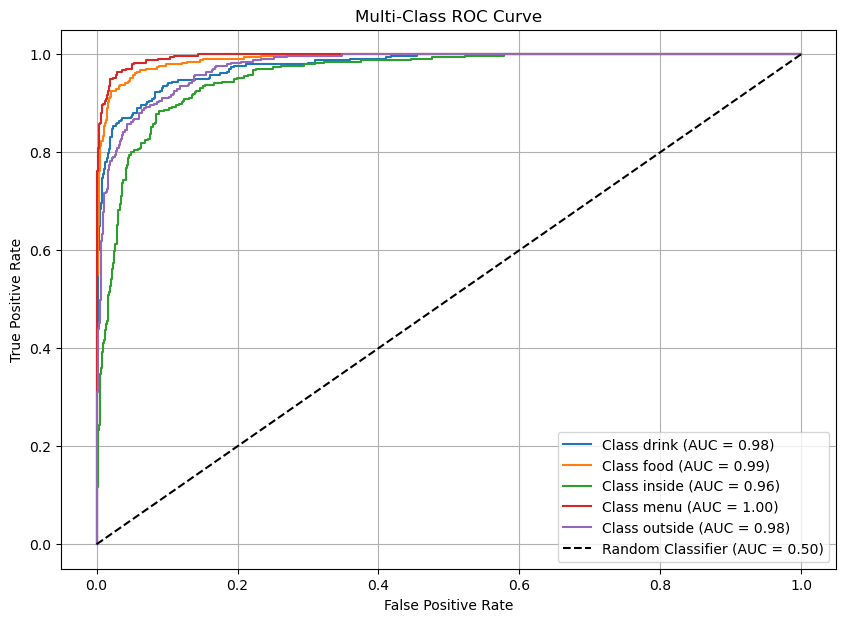

In [30]:
# Assuming model is already created and trained as in your provided code.

# Get predictions (probabilities)
y_pred_probs = model.predict(X_test_features)

# Convert predicted probabilities to class labels (index positions)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# --- Plot Confusion Matrix ---
cm = confusion_matrix(y_test_encoded, y_pred_classes)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# --- Compute AUC for Multi-Class ROC Curve ---
roc_auc = roc_auc_score(y_test_encoded, y_pred_probs, average='macro', multi_class='ovr')
print(f"AUC (macro-average): {roc_auc}")

# Plot ROC Curves for each class
plt.figure(figsize=(10, 7))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_pred_probs[:, i])
    roc_auc_class = auc(fpr, tpr)  # AUC for each class
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc_class:.2f})')

# Plot diagonal line (chance)
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


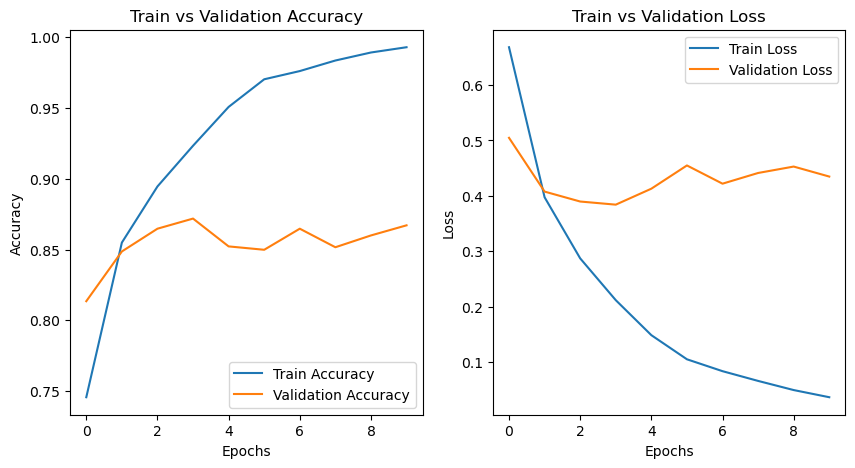

In [31]:
# Plot accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Validation Loss')

plt.show()


Analysis:
Train vs Validation Accuracy :

Training accuracy is increasing steadily and reaches almost 100%.

Validation accuracy remains constant and fluctuates around 85%-87%.

Train vs Validation Loss:

Training loss is continuously decreasing, indicating the model is learning from training data.

Validation loss remains stagnant and fluctuates, showing that the model is not generalizing well.

Conclusion: Your Model is Overfitting


### L2 Regularization

In [32]:
# Load VGG16 as base model (without top layers)
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze VGG16 layers to prevent training
base_model.trainable = False

# Define input layers
image_input = Input(shape=(224, 224, 3))  # Input for images
features_input = Input(shape=(64,))  # Input for additional features (Ensure it's correct)

# Pass image input through VGG16
x = base_model(image_input)
x = Flatten()(x)  # Flatten the image output to 1D

# Concatenate image and feature inputs
merged = Concatenate()([x, features_input])

# Add Dense layers with L2 Regularization
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(merged)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)

# Output layer for classification
outputs = Dense(num_classes, activation='softmax')(x)  # Replace `num_classes`

# Create the model
model = Model(inputs=[image_input, features_input], outputs=outputs)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 7, 7, 512)         │      14,714,688 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 25088)             │               0 │ vgg16[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_8 (InputLayer)    │ (None, 64)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 25152)             │               0 │ flatten[0][0],             │
│                               │                           │                 │ input_layer_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 128)               │       3,219,584 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 64)                │           8,256 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 5)                 │             325 │ dense_11[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 17,942,853 (68.45 MB)

 Trainable params: 3,228,165 (12.31 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [41]:
print(type(X_train))
print(X_train.shape)  # If it exists, check its shape


<class 'numpy.ndarray'>
(6706, 224, 224, 3)


In [48]:
print(type(X_train_features))  # Should be <class 'numpy.ndarray'>
print(X_train_features.shape)  # Should match (6706, 25088)

print(type(y_train))  # Should be <class 'numpy.ndarray'> or a compatible data type
print(y_train.dtype)  # Should be an integer type if using sparse_categorical_crossentropy


<class 'numpy.ndarray'>
(6706, 25088)
<class 'numpy.ndarray'>
<U7


## Model training after L2 regularization

In [49]:
# 1. Encode the string labels into integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Encode y_train labels
y_test_encoded = label_encoder.transform(y_test)  # Encode y_test labels

# Check encoded labels
print(np.unique(y_train_encoded))  # Should print the integer classes
print(y_train_encoded[:10])  # First 10 encoded labels

# 2. Define the model

# Define input for VGG16 features
input_vgg = Input(shape=(25088,), name="input_vgg")

# Define input for additional features (if needed)
input_extra = Input(shape=(64,), name="input_extra")  # Assuming 64 extra features

# Concatenate features
concat = Concatenate()([input_vgg, input_extra])

# Fully connected layers
x = Dense(128, activation='relu')(concat)
x = Dense(64, activation='relu')(x)
output_layer = Dense(5, activation='softmax')(x)  # Assuming 5 classes

# Define model with both inputs
model = Model(inputs=[input_vgg, input_extra], outputs=output_layer)

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Ensure correct data types
X_train_features = np.array(X_train_features, dtype=np.float32)
X_test_features = np.array(X_test_features, dtype=np.float32)
y_train_encoded = np.array(y_train_encoded, dtype=np.int32)
y_test_encoded = np.array(y_test_encoded, dtype=np.int32)

# 4. Generate random extra feature data (since additional_input_data is missing)
additional_input_data = np.random.rand(6706, 64)  # Train set extra features
additional_test_input_data = np.random.rand(1678, 64)  # Test set extra features

# 5. Train the model
history = model.fit(
    [X_train_features, additional_input_data],  # Pass both feature inputs
    y_train_encoded,  # Pass encoded labels
    validation_data=([X_test_features, additional_test_input_data], y_test_encoded),
    epochs=10,
    batch_size=32
)

[0 1 2 3 4]
[4 1 3 1 3 2 2 4 1 2]
Epoch 1/10


C:\Users\JISNA\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_vgg', 'input_extra']. Received: the structure of inputs=('*', '*')
  warnings.warn(


210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6721 - loss: 0.8892 - val_accuracy: 0.8480 - val_loss: 0.4325
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9097 - loss: 0.2573 - val_accuracy: 0.8415 - val_loss: 0.4767
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9541 - loss: 0.1363 - val_accuracy: 0.8266 - val_loss: 0.5582
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9793 - loss: 0.0786 - val_accuracy: 0.8319 - val_loss: 0.5804
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9893 - loss: 0.0393 - val_accuracy: 0.8558 - val_loss: 0.6007
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9863 - loss: 0.0433 - val_accuracy: 0.8510 - val_loss: 0.6334
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9974 - loss: 0.0135 - val_accuracy: 0.8492 - val_loss: 0.7386
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9970 - loss: 0.0115 - val_accuracy: 0.851

## Confusion matrix and ROC

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<Figure size 800x600 with 0 Axes>

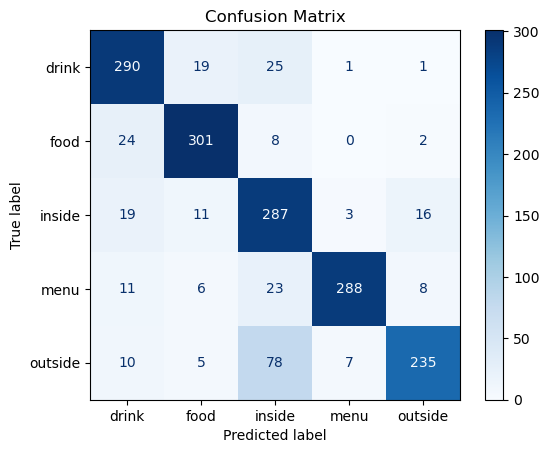

AUC (macro-average): 0.9696744303258438


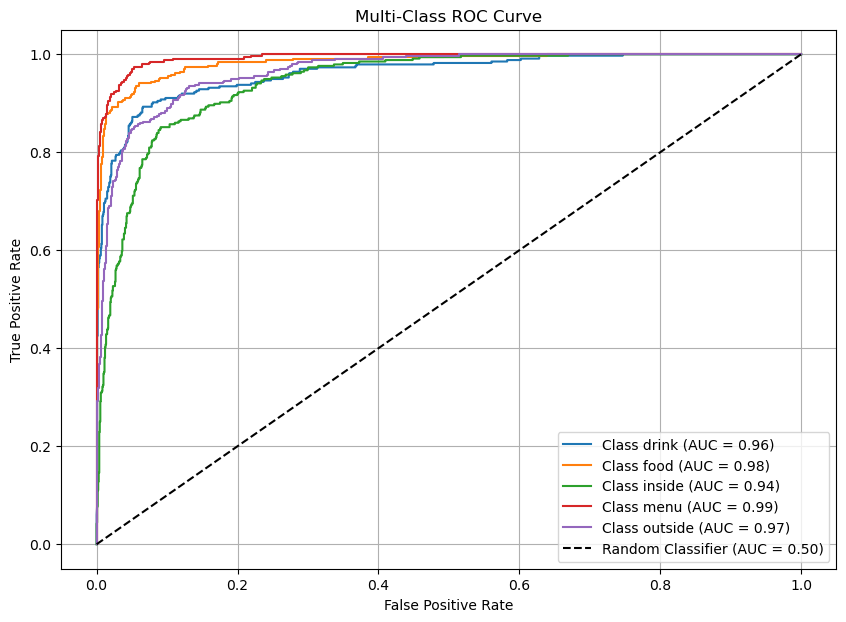

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
import numpy as np

# Assuming model is already created and trained as in your provided code

# Get predictions (probabilities) for test data
y_pred_probs = model.predict([X_test_features, additional_test_input_data])  # For your model with extra input data

# Convert predicted probabilities to class labels (index positions)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# --- Plot Confusion Matrix ---
cm = confusion_matrix(y_test_encoded, y_pred_classes)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# --- Compute AUC for Multi-Class ROC Curve ---
roc_auc = roc_auc_score(y_test_encoded, y_pred_probs, average='macro', multi_class='ovr')
print(f"AUC (macro-average): {roc_auc}")

# --- Plot ROC Curves for Each Class ---
plt.figure(figsize=(10, 7))
for i in range(len(label_encoder.classes_)):  # Loop through each class
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_pred_probs[:, i])  # Compute ROC curve for each class
    roc_auc_class = auc(fpr, tpr)  # AUC for each class
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc_class:.2f})')

# Plot diagonal line (chance line)
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.50)")

# Customize plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


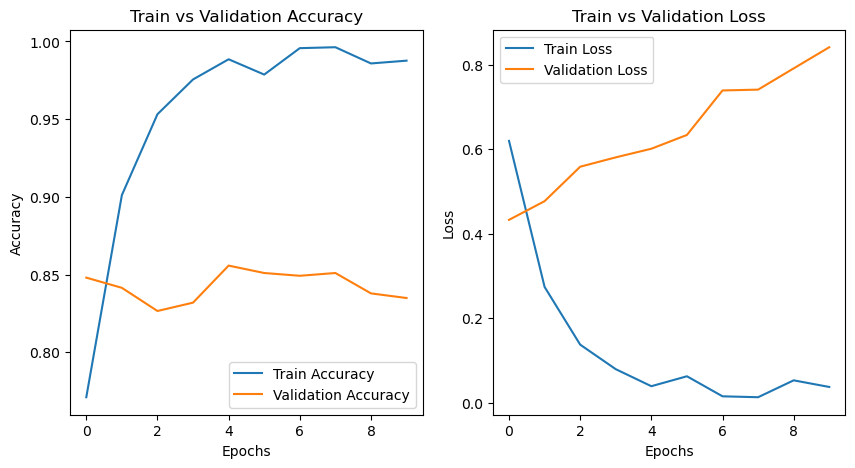

In [52]:
# Plot accuracy
plt.figure(figsize=(10, 5))

# Plot training vs validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')

# Plot training vs validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Validation Loss')

# Show the plots
plt.show()

In [63]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate([X_test_features, additional_test_input_data], y_test_encoded)

# Print test loss and accuracy
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8512 - loss: 0.7683
Test Loss: 0.8409
Test Accuracy: 0.8349


## LIME

In [54]:
from lime.lime_tabular import LimeTabularExplainer

# Combine features to match the model's input
# This will combine X_train_features and additional_input_data for LIME
train_data = np.concatenate([X_train_features, additional_input_data], axis=1)

# Create a LIME explainer
explainer = LimeTabularExplainer(
    train_data,  # Training data (combined features)
    training_labels=y_train,  # Labels for training data
    mode='classification',  # This is a classification problem
    feature_names=[f"feature_{i}" for i in range(train_data.shape[1])],  # Generate feature names
    class_names=[str(i) for i in range(5)],  # 5 classes as per your model
    discretize_continuous=True  # Discretize continuous features for better interpretability
)

# Choose an instance to explain (e.g., first instance of the test set)
instance_to_explain = np.concatenate([X_test_features[0], additional_test_input_data[0]])

# Function to predict probabilities for LIME
def predict_proba(input_data):
    # Since the model expects two inputs, we split input_data accordingly
    vgg_input = input_data[:, :25088]  # The first part corresponds to the VGG features
    extra_input = input_data[:, 25088:]  # The second part corresponds to additional features
    return model.predict([vgg_input, extra_input])

# Explain the chosen instance using LIME
explanation = explainer.explain_instance(instance_to_explain, predict_proba)

# Visualize the explanation
explanation.show_in_notebook()


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


## Round 1 - Hyperparameter tuning

In [58]:
!pip install scikeras

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# Define function to create your model with adjustable hyperparameters
def create_model(hidden_units_1=128, hidden_units_2=64, optimizer='adam'):
    input_vgg = Input(shape=(25088,), name="input_vgg")
    input_extra = Input(shape=(64,), name="input_extra")

    concat = Concatenate()([input_vgg, input_extra])
    x = Dense(hidden_units_1, activation='relu')(concat)
    x = Dense(hidden_units_2, activation='relu')(x)
    output_layer = Dense(5, activation='softmax')(x)

    model = Model(inputs=[input_vgg, input_extra], outputs=output_layer)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Wrap the model into a KerasClassifier for use in GridSearchCV
model = KerasClassifier(build_fn=create_model, verbose=0)

# Define the parameter grid for the first round of tuning
param_grid = {
    'batch_size': [32, 64, 128],
    'epochs': [5, 10, 15],
    'hidden_units_1': [64, 128, 256],
    'hidden_units_2': [32, 64, 128],
    'optimizer': ['adam', 'rmsprop']
}

# Perform GridSearchCV for the first round of tuning
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=2)
grid_result = grid.fit(
    [X_train_features, additional_input_data],  # Training data
    y_train
)

# Print the best parameters and the best score from round 1
print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

# Save the best model
best_model = grid_result.best_estimator_


ImportError: cannot import name 'get_tags' from 'sklearn.utils._tags' (C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\utils\_tags.py)

## Round 2 - Hyperparameter tuning

In [ ]:
from keras.optimizers import Adam, RMSprop

# Define the second round of parameter grid for tuning the learning rate and optimizer
param_grid_round_2 = {
    'batch_size': [32, 64],
    'epochs': [5, 10],
    'hidden_units_1': [128],
    'hidden_units_2': [64],
    'optimizer': [Adam, RMSprop],
    'learning_rate': [0.001, 0.0005, 0.0001]
}

# Define the function to create the model with a learning rate
def create_model_with_lr(hidden_units_1=128, hidden_units_2=64, optimizer=Adam, learning_rate=0.001):
    input_vgg = Input(shape=(25088,), name="input_vgg")
    input_extra = Input(shape=(64,), name="input_extra")

    concat = Concatenate()([input_vgg, input_extra])
    x = Dense(hidden_units_1, activation='relu')(concat)
    x = Dense(hidden_units_2, activation='relu')(x)
    output_layer = Dense(5, activation='softmax')(x)

    model = Model(inputs=[input_vgg, input_extra], outputs=output_layer)

    # Apply learning rate to the optimizer
    optimizer_instance = optimizer(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_instance, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

# Wrap the model into a KerasClassifier again for use in GridSearchCV
model_round_2 = KerasClassifier(build_fn=create_model_with_lr, verbose=0)

# Perform GridSearchCV for the second round of tuning
grid_round_2 = GridSearchCV(estimator=model_round_2, param_grid=param_grid_round_2, cv=3, verbose=2)
grid_result_round_2 = grid_round_2.fit(
    [X_train_features, additional_input_data],  # Training data
    y_train
)

# Print the best parameters and the best score from round 2
print(f"Best: {grid_result_round_2.best_score_} using {grid_result_round_2.best_params_}")
